In [5]:
from google.colab import files
uploaded = files.upload()

Saving Phase1_Product_Validation.xlsx.xlsx to Phase1_Product_Validation.xlsx.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',None)

In [7]:
df = pd.read_excel("Phase1_Product_Validation.xlsx.xlsx")

In [8]:
df. head()

,Dish_Name,Protein_Type,Base_Price_KES,Estimated_Cost_KES,Gross_Margin_KES,Margin_Percentage,Pairing_Item,Order_Frequency,Frequency_Score,Customer_Preference_Score,Prep_Time_Minutes,Packaging_Type,Demand_Stability,Profitability_Level,Status
0,Ugali + Beef,Beef,150,90,60,40.0,Vegetables,High,3,4,60,Standard,Stable,Medium,Continued
1,Ugali + Fish,Fish,250,160,90,36.0,Salad/Vegetables,Medium,2,3,60,Standard,Irregular,Low,Continued
2,Beef Pilau,Beef,250,110,140,56.0,Salad + Banana,High,3,5,60,Standard,Stable,High,Continued
3,Chapati + Beef,Beef,150,80,70,46.7,Steamed Cabbage,High,3,5,120,Basic,Stable,High,Continued
4,Rice + Beef,Beef,250,100,150,60.0,Salad,Medium,2,4,60,Basic,Stable,Medium,Continued


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Dish_Name                  10 non-null     object 
 1   Protein_Type               10 non-null     object 
 2   Base_Price_KES             10 non-null     int64  
 3   Estimated_Cost_KES         10 non-null     int64  
 4   Gross_Margin_KES           10 non-null     int64  
 5   Margin_Percentage          10 non-null     float64
 6   Pairing_Item               10 non-null     object 
 7   Order_Frequency            10 non-null     object 
 8   Frequency_Score            10 non-null     int64  
 9   Customer_Preference_Score  10 non-null     int64  
 10  Prep_Time_Minutes          10 non-null     int64  
 11  Packaging_Type             10 non-null     object 
 12  Demand_Stability           10 non-null     object 
 13  Profitability_Level        10 non-null     object 
 1

Statistical Summary

In [10]:
df.describe()

,Base_Price_KES,Estimated_Cost_KES,Gross_Margin_KES,Margin_Percentage,Frequency_Score,Customer_Preference_Score,Prep_Time_Minutes
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,245.00000,127.000000,118.000000,48.380000,2.500000,4.200000,72.000000
std,59.86095,44.981478,32.930904,9.562984,0.707107,0.788811,25.298221
min,150.00000,80.000000,60.000000,36.000000,1.000000,3.000000,60.000000
25%,250.00000,100.000000,97.500000,40.000000,2.000000,4.000000,60.000000
50%,250.00000,110.000000,130.000000,49.350000,3.000000,4.000000,60.000000
75%,250.00000,150.000000,140.000000,56.000000,3.000000,5.000000,60.000000
max,350.00000,220.000000,150.000000,60.000000,3.000000,5.000000,120.000000


Derived Columns

Gross Margin

In [13]:
df["Gross Margin"]= df['Base_Price_KES']-df["Estimated_Cost_KES"]

Margin Percentage

In [15]:
df["Margin%"]= (df['Gross Margin'])/ df["Base_Price_KES"]*100

Profit Per Minute

In [17]:
df["Profit per Minute"]= df["Prep_Time_Minutes"]

Univariate Analysis

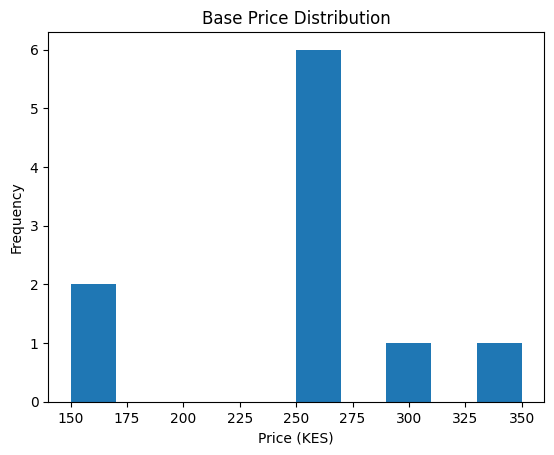

In [18]:
df['Base_Price_KES'].plot(kind="hist")
plt.title("Base Price Distribution")
plt.xlabel("Price (KES)")
plt.ylabel("Frequency")
plt.show()

Profitability Distribution

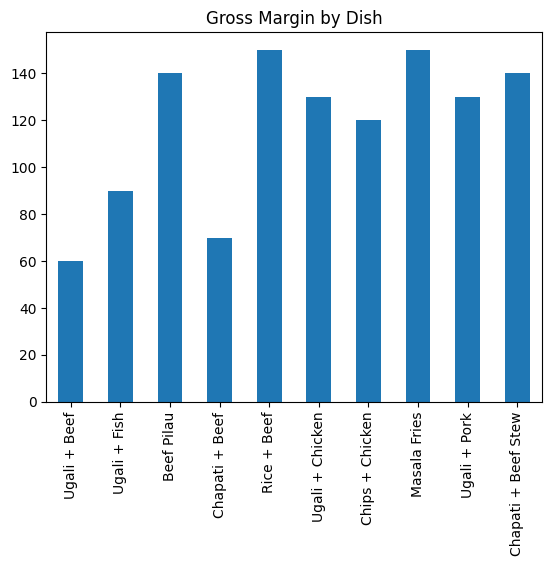

In [20]:
df["Gross Margin"].plot(kind="bar")
plt.title("Gross Margin by Dish")
plt.xticks(range(len(df)),df["Dish_Name"], rotation=90)
plt.show()

Preference Analysis

In [22]:
df.sort_values("Customer_Preference_Score",ascending=False)[["Dish_Name","Customer_Preference_Score"]]

,Dish_Name,Customer_Preference_Score
3,Chapati + Beef,5
2,Beef Pilau,5
8,Ugali + Pork,5
6,Chips + Chicken,5
7,Masala Fries,4
0,Ugali + Beef,4
9,Chapati + Beef Stew,4
4,Rice + Beef,4
1,Ugali + Fish,3
5,Ugali + Chicken,3


Profitability vs Preference


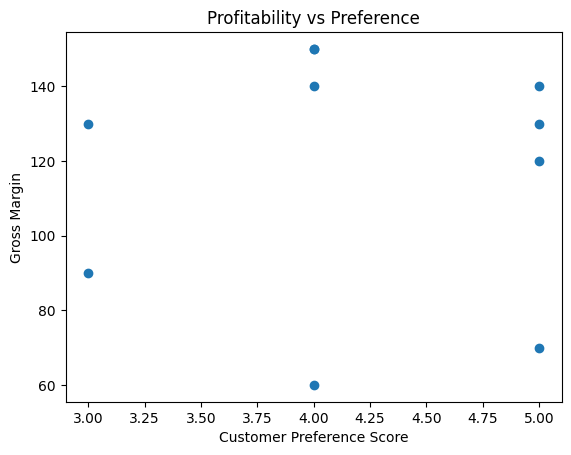

In [23]:
plt.scatter(df["Customer_Preference_Score"],df["Gross Margin"])
plt.title("Profitability vs Preference")
plt.xlabel("Customer Preference Score")
plt.ylabel("Gross Margin")
plt.show()

Product Survival Analysis

In [24]:
df["Status"].value_counts()

,count
Status,
Continued,9
Discontinued,1


Visual

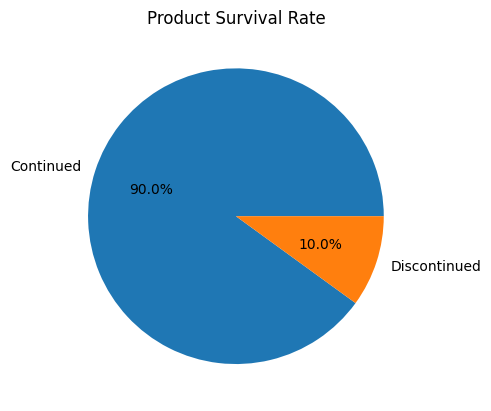

In [25]:
df["Status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Product Survival Rate")
plt.ylabel("")
plt.show()

Protein Dominance Analysis

In [28]:
df["Protein_Type"]= df['Dish_Name'].str.extract("(Beef|Chicken|Fish|Pork)")

Count

In [29]:
df["Protein_Type"].value_counts()

,count
Protein_Type,
Beef,5
Chicken,2
Fish,1
Pork,1


Plot

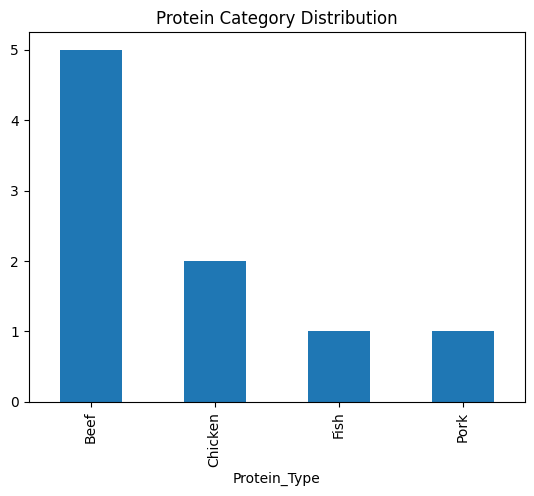

In [31]:
df["Protein_Type"].value_counts().plot(kind="bar")
plt.title("Protein Category Distribution")
plt.ylabel("")
plt.show()

Operational Complexity Analysis

Average Prep Time

In [33]:
df.groupby("Packaging_Type")["Prep_Time_Minutes"].mean()

,Prep_Time_Minutes
Packaging_Type,
Basic,72.0
Standard,72.0


Visual

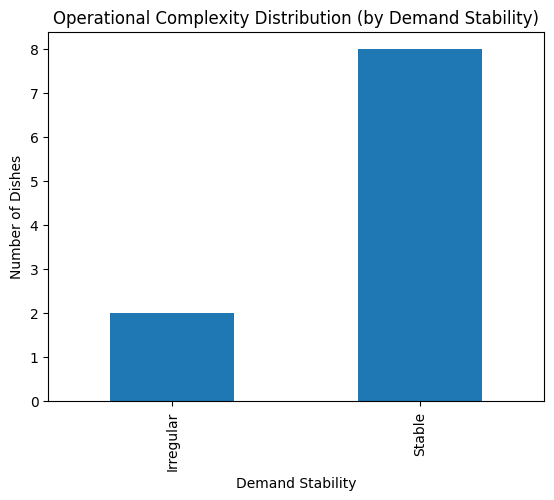

In [35]:
df.groupby("Demand_Stability").size().plot(kind="bar")
plt.title("Operational Complexity Distribution (by Demand Stability)")
plt.xlabel("Demand Stability")
plt.ylabel("Number of Dishes")
plt.show()

Demand Stability Analysis

In [36]:
df["Demand_Stability"].value_counts()

,count
Demand_Stability,
Stable,8
Irregular,2


Visual

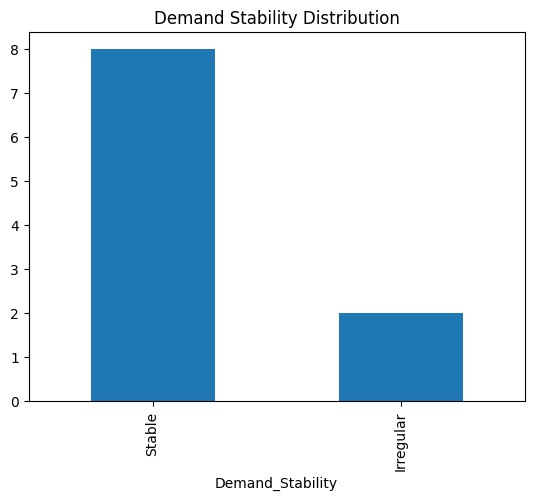

In [38]:
df["Demand_Stability"].value_counts().plot(kind="bar")
plt.title("Demand Stability Distribution")
plt.ylabel("")
plt.show()

Risk Analysis

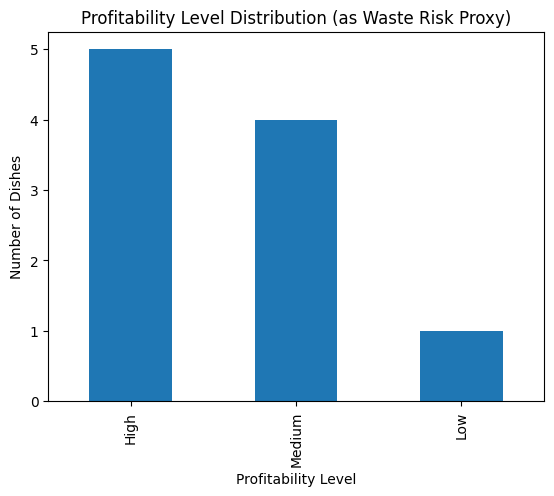

In [40]:
df["Profitability_Level"].value_counts().plot(kind="bar")
plt.title("Profitability Level Distribution (as Waste Risk Proxy)")
plt.xlabel("Profitability Level")
plt.ylabel("Number of Dishes")
plt.show()

Final Business Summary

Top Profitable Dish

In [42]:
df.loc[df["Gross Margin"].idxmax()]

,4
Dish_Name,Rice + Beef
Protein_Type,Beef
Base_Price_KES,250
Estimated_Cost_KES,100
Gross_Margin_KES,150
Margin_Percentage,60.0
Pairing_Item,Salad
Order_Frequency,Medium
Frequency_Score,2
Customer_Preference_Score,4


Lowest Profitable Dish

In [43]:
df.loc[df['Gross Margin'].idxmin()]

,0
Dish_Name,Ugali + Beef
Protein_Type,Beef
Base_Price_KES,150
Estimated_Cost_KES,90
Gross_Margin_KES,60
Margin_Percentage,40.0
Pairing_Item,Vegetables
Order_Frequency,High
Frequency_Score,3
Customer_Preference_Score,4


Best Margin Efficienecy

In [44]:
df.loc[df["Margin%"].idxmax()]

,4
Dish_Name,Rice + Beef
Protein_Type,Beef
Base_Price_KES,250
Estimated_Cost_KES,100
Gross_Margin_KES,150
Margin_Percentage,60.0
Pairing_Item,Salad
Order_Frequency,Medium
Frequency_Score,2
Customer_Preference_Score,4
